# Lab 5: First-year first-time student dropout detection - CNN
---

Grupo 3 \
Alexandre Rodrigues: 75545 \
Tiago Granja: 79845 \
Diogo Silva: 79828

Import libraries

In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from imblearn.over_sampling import SMOTE

## First-year first-time student dropout

First-year first-time student dropout is an issue for universities worldwide, with far-reaching consequences that extend beyond individual students to affect institutions and society at large. Deep learning techniques are a promising approach to early detection of student at risk. In this assignment we'll tackle this problem with the use of Convolutional Neural Networks (CNNs).

## Dataset

The dataset used refers to the data available until the academic year 2024/2025 and has 42102 students, where each is composed of 26 sociodemographic and academic features, such as Age, Nationality, chosen course, and their status regarding dropout.

In [2]:
data_frame = pd.read_csv("training_data_V2.0.csv")
print(data_frame)

       Age         Nationality1 Nationality2              Locality  \
0       42             Portugal      Unknown                  FARO   
1       36             Portugal      Unknown                  FARO   
2       38             Portugal      Unknown                  FARO   
3       33             Portugal      Unknown                 OLHÃO   
4       38             Portugal      Unknown  SÃO BRÁS DE ALPORTEL   
...    ...                  ...          ...                   ...   
42097   25  São Tomé e Príncipe      Unknown                  FARO   
42098   19           Moçambique      Unknown                  FARO   
42099   18         Guiné-Bissau      Unknown                  FARO   
42100   23         Guiné-Bissau      Unknown               Unknown   
42101   21         Guiné-Bissau      Unknown               AMADORA   

      Special Need Support               Student Type  \
0               No      No  Estudante a Tempo Inteiro   
1               No      No  Estudante a Tempo

#### Dealing with unknown values

In our dataset, several columns include unknown values, resulting in ambiguity. Due to this, such values must be properly addressed before training. Encoding these values is one initial way to approach this problem, however, we would leave room for our model to learn patterns taking into account these unknown ambiguous values, something that we'd rather avoid. To avoid this, we aim to delete all unknown values from our training dataset by first dropping columns that are composed by mostly unknown values, and only after deleting any remaining entry that may still contain unknown values. We determine if a column is composed by mostly unknown values with a use of a threshold $t$. We also drop te column regarding the academic year, as it doesn't add any information.

In [3]:
unknown_threshold = 0.5

data_frame = data_frame.drop(columns="Academic Year")
data_frame = data_frame.loc[:, (data_frame == "Unknown").mean() <= unknown_threshold]
data_frame = data_frame[~(data_frame == "Unknown").any(axis=1)]
    
print(data_frame)

       Age Nationality1        Locality Special Need Support  \
123     25     Portugal           LOULÉ           No      No   
305     20     Portugal         MÉRTOLA           No      No   
441     18     Portugal            FARO           No      No   
607     24     Portugal            FARO           No      No   
1362    21     Portugal         MÉRTOLA           No      No   
...    ...          ...             ...          ...     ...   
42073   18     Portugal  ALCÁCER DO SAL           No      No   
42074   18     Portugal           OLHÃO           No      No   
42075   20     Portugal       QUARTEIRA           No      No   
42076   19     Portugal           MAFRA           No      No   
42077   19     Portugal          NAZARÉ           No      No   

                                        Student Type  \
123                        Estudante a Tempo Inteiro   
305                        Estudante a Tempo Inteiro   
441                        Estudante a Tempo Inteiro   
607    

With $t = 0.5$, we delete 6 columns and maintain 19001 entries in our dataset.

In [4]:
remaining_columns = data_frame.columns

print(remaining_columns)

Index(['Age', 'Nationality1', 'Locality', 'Special Need', 'Support',
       'Student Type', 'Professional Situation', 'Professional Group',
       'Mother's Habilitation', 'Mother's Professional Situation',
       'Mother's Professional Group', 'Father's Habilitation',
       'Father's Professional Group', 'Father's Professional Situation',
       'Course', 'Faculty', 'Scholarship', 'Admission', 'Status', 'DGES Info',
       'Admission Grade'],
      dtype='str')


In [5]:
for column in remaining_columns:
    print(column)
    print(data_frame[column].unique())

Age
[25 20 18 24 21 19 28 23 22 36 26 17 32 40 29 30 34 31 38 27 41 49 46 33
 37 35 44 45 39 42 47 43 60 58 50 61 16 52 53  0 48 14 57 54 64 56 59 55
 68]
Nationality1
<StringArray>
[                           'Portugal',                          'Cabo Verde',
                              'Itália',                        'Guiné-Bissau',
               'Rússia (Federação da)',                              'Brasil',
                            'Alemanha',                              'França',
               'Moldova, República de',                          'Moçambique',
                             'Ucrânia',                             'Roménia',
                              'Angola',                       'Países Baixos',
                         'Reino Unido',                             'Espanha',
                            'Colômbia',                           'Austrália',
                             'Bélgica',                 'São Tomé e Príncipe',
                         'Ca

#### Handling anomalies

By briefly inspecting the remaining of the original dataset, we still find some anomalies such as student with age '0' or the student types " .. ", ":", ".". We also convert the admission grade to a float.

In [6]:
data_frame = data_frame[data_frame["Age"] != 0]
data_frame = data_frame[data_frame["Student Type"] != " .. "]
data_frame = data_frame[data_frame["Student Type"] != ":"]
data_frame = data_frame[data_frame["Student Type"] != "."]
data_frame["Admission Grade"] = data_frame["Admission Grade"].astype(float)

#### Encoding categorical values

To encode the categorical values found in our dataset, we resort to one-hot encoding them. This was preferred over label encoding to avoid unintentional ordinal relationships, despite its simplicity and memory efficiency.

In [7]:
def one_hot_encode(data_frame: pd.DataFrame, column: str) -> pd.DataFrame:
    one_hot = one_hot = pd.get_dummies(data_frame[column]).astype(int)
    data_frame = data_frame.drop(columns=column)
    data_frame = data_frame.join(one_hot, lsuffix=column)
    return data_frame

In [8]:
one_hot_columns = ["Nationality1", "Locality", "Special Need", "Support", "Student Type", "Professional Situation", "Professional Group", 
                   "Mother's Habilitation", "Mother's Professional Situation", "Mother's Professional Group", 
                   "Father's Habilitation", "Father's Professional Group", "Father's Professional Situation",
                   "Course", "Faculty", "Scholarship", "Admission", "DGES Info"]

for column in one_hot_columns:
    data_frame = one_hot_encode(data_frame, column)

print(data_frame)

       Age  Status  Admission Grade  Alemanha  Angola  Argélia  Austrália  \
123     25       0            135.0         0       0        0          0   
305     20       0            126.0         0       0        0          0   
441     18       0            146.0         0       0        0          0   
607     24       0            120.0         0       0        0          0   
1362    21       0            126.0         0       0        0          0   
...    ...     ...              ...       ...     ...      ...        ...   
42073   18       0            136.3         0       0        0          0   
42074   18       0            152.9         0       0        0          0   
42075   20       0            131.8         0       0        0          0   
42076   19       0            133.7         0       0        0          0   
42077   19       0            146.7         0       0        0          0   

       Brasil  Bulgária  Bélgica  ...  \
123         0         0        0  

With this, we greatly increase the dimensionality of our dataset, which must be properly addressed to be used in a CNN.  

In [9]:
def print_dataset(x: np.ndarray, y: np.ndarray) -> None:
    print(f"X {x.shape}:")
    print(x)
    print(f"\nY {y.shape}:")
    print(y)

In [10]:
x = data_frame.loc[:, data_frame.columns != "Status"].to_numpy()
y = data_frame["Status"].to_numpy()
y = np.reshape(y, (-1, 1))

print_dataset(x, y)

X (18951, 1469):
[[ 25.  135.    0.  ...   0.    0.    0. ]
 [ 20.  126.    0.  ...   0.    0.    0. ]
 [ 18.  146.    0.  ...   0.    0.    0. ]
 ...
 [ 20.  131.8   0.  ...   0.    0.    0. ]
 [ 19.  133.7   0.  ...   0.    0.    0. ]
 [ 19.  146.7   0.  ...   0.    0.    0. ]]

Y (18951, 1):
[[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]


#### Encoding and embedding pipeline

With this, our initial pipeline of encoding and embedding the original data is complete and given as such:

In [11]:
def encode(data_frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    data_frame = data_frame.drop(columns="Academic Year")
    data_frame = data_frame[remaining_columns]
    data_frame["Admission Grade"] = data_frame["Admission Grade"].astype(float)
    for column in one_hot_columns:
        data_frame = one_hot_encode(data_frame, column)

    x = data_frame.loc[:, data_frame.columns != "Status"].to_numpy()
    y = data_frame["Status"].to_numpy()
    return (x, y)

#### Class imbalance

Our dataset is imbalanced, where most of our samples regard students, that didn't dropout, which could result in a biased model if left unaddressed. To attenuate this, we'll use SMOTE to balance out the class imbalance in the training dataset, which consists of 80% of our entire dataset.

In [12]:
def print_class_frequency(y: np.ndarray) -> None:
    unique, count = np.unique(y, return_counts=True)
    print(unique)
    print(count)

In [13]:
print_class_frequency(y)

[0 1]
[16998  1953]


In [14]:
training_percentage = 0.8
training_size = int(x.shape[0] * training_percentage)

x_train = x[:training_size]
x_test = x[training_size:]
y_train = y[:training_size]
y_test = y[training_size:]

print(f"Training size = {x_train.shape[0]}")
print(f"Testing size = {x_test.shape[0]}")

Training size = 15160
Testing size = 3791


In [15]:
print_class_frequency(y_train)

[0 1]
[13644  1516]


#### Synthetic Minority Oversampling Technique (SMOTE)

SMOTE was used to generate samples for the minority class. SMOTE works by interpolating new samples from the minority class using $k$ neighbors.

In [16]:
smote = SMOTE(sampling_strategy=1)
x_train, y_train = smote.fit_resample(x_train, y_train)
y_train = np.reshape(y_train, (-1, 1))

print_class_frequency(y_train)

[0 1]
[13644 13644]


## Implemented model

Our model is composed of three main components:
- A first, "encoding" dense layer with 1024 neurons, with the objective of encoding our tabular data in a 32 by 32 "image".
- The core of our networks, two 2D convolutional layers, with max pooling in between and at the end of the block.
- A final, small 128\:64\:1 MLP that classifies a student given the features extracted by the previous CNN block, with a sigmoid output.

All hidden and convolution layers use a ReLu activation function for their respective output and are applied L2 regularization. Convolutional layers use a 3x3 window and learn 32 filters. Max pooling is applied with the use of a 2x2 window.

#### The first layer

CNNs are widely recognized for their effectiveness in computer vision tasks, such as recognizing handwritten digits, however this spatial information capturing ability does not directly apply to tabular datasets that lack spatial correlation. [1] The motivation behind this layer is to, during training, encode our input in a way that the following CNN can capture features from this encoding. For our model we chose a 32x32 image representation, to which we then apply usual 2D CNN operations and follow it with a small MLP for final classification.

In [17]:
l2_reg = 0.002

cnn_model = keras.Sequential([    
    keras.Input(shape=(x.shape[1],)),
    layers.Dense(1024, activation='relu', kernel_regularizer=keras.regularizers.l2(l2_reg)),
    layers.Reshape(target_shape=(32, 32, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", kernel_regularizer=keras.regularizers.l2(l2_reg)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", kernel_regularizer=keras.regularizers.l2(l2_reg)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(l2_reg)),
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(l2_reg)),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(loss="binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy", "precision", "recall", tf.keras.metrics.F1Score(threshold=0.5)])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     1,505,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,670,753 (6.37 MB)

 Trainable params: 1,670,753 (6.37 MB)

 Non-trainable params: 0 (0.00 B)

## Training

For training, we used the binary cross entropy loss function as it is suited for binary classification problems. For our optimizer we use the ADAM optimizer with a learning rate of $0.0001$. Early stop is employed from epoch 10 and onwards with patience value set to 3, considering improvements lower than $10^{-4}$ as not significant.

In [18]:
batch_size = 128
epochs = 100
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, min_delta=10e-4, start_from_epoch=10)

training_history = cnn_model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, shuffle=True, 
                           callbacks=[early_stop], validation_data=(x_test, y_test))

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5291 - f1_score: 0.4729 - loss: 2.5773 - precision: 0.5370 - recall: 0.4225 - val_accuracy: 0.8847 - val_f1_score: 0.0000e+00 - val_loss: 1.6437 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5755 - f1_score: 0.5386 - loss: 1.3628 - precision: 0.5898 - recall: 0.4956 - val_accuracy: 0.6252 - val_f1_score: 0.2920 - val_loss: 1.1096 - val_precision: 0.1866 - val_recall: 0.6705
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6110 - f1_score: 0.5940 - loss: 1.0071 - precision: 0.6212 - recall: 0.5690 - val_accuracy: 0.5838 - val_f1_score: 0.2821 - val_loss: 0.9213 - val_precision: 0.1760 - val_recall: 0.7094
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6547 - f1_score: 0.6666 - loss: 0.8811 - precision: 0.6444 - recall: 0.6903 - val_accuracy: 0.6661 - val_f1_score: 0.3006 - val_loss: 0.7972 - val_precision: 0.19

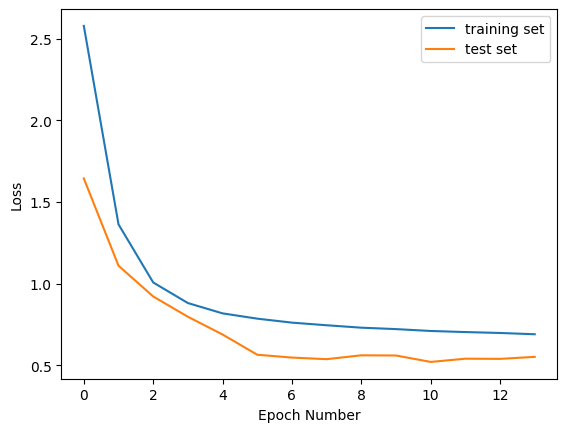

In [19]:
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.plot(training_history.history['loss'], label='training set')
plt.plot(training_history.history['val_loss'], label='test set')
plt.legend()

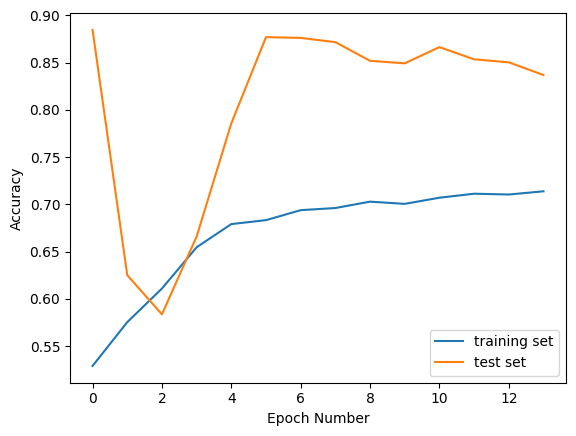

In [20]:
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.plot(training_history.history['accuracy'], label='training set')
plt.plot(training_history.history['val_accuracy'], label='test set')
plt.legend()

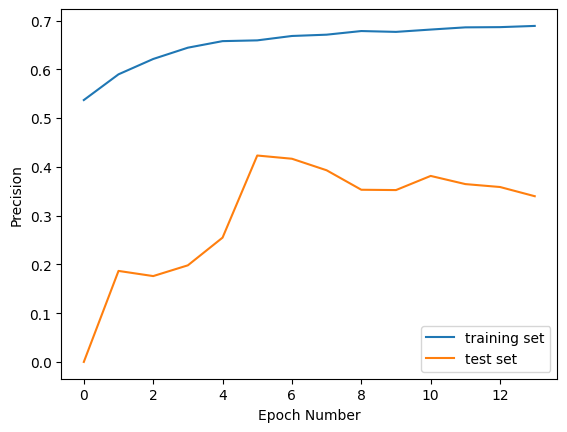

In [21]:
plt.xlabel('Epoch Number')
plt.ylabel('Precision')
plt.plot(training_history.history['precision'], label='training set')
plt.plot(training_history.history['val_precision'], label='test set')
plt.legend()

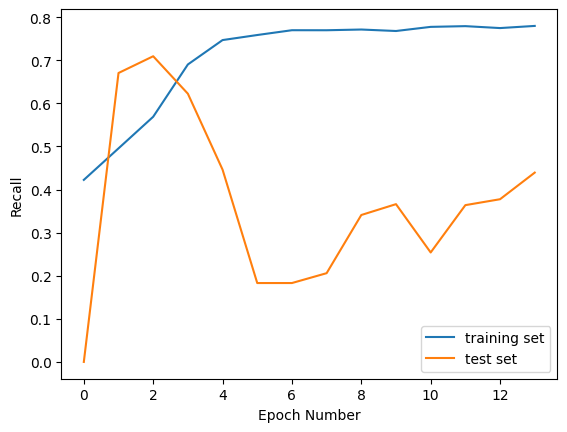

In [22]:
plt.xlabel('Epoch Number')
plt.ylabel('Recall')
plt.plot(training_history.history['recall'], label='training set')
plt.plot(training_history.history['val_recall'], label='test set')
plt.legend()

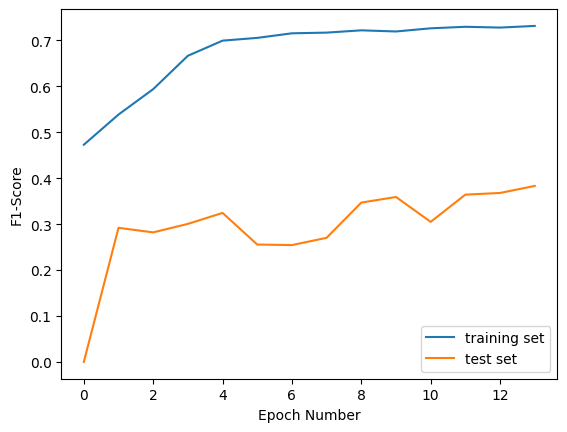

In [23]:
plt.xlabel('Epoch Number')
plt.ylabel('F1-Score')
plt.plot(training_history.history['f1_score'], label='training set')
plt.plot(training_history.history['val_f1_score'], label='test set')
plt.legend()

## Model performance

In [24]:
score = cnn_model.evaluate(x_train, y_train)
print("Train loss:", score[0])
print("Train accuracy:", score[1])
print("Train precision:", score[2])
print("Train recall:", score[3])
print("Train f1-score:", score[4])

853/853 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7227 - f1_score: 0.7552 - loss: 0.6795 - precision: 0.6760 - recall: 0.8553
Train loss: 0.679487407207489
Train accuracy: 0.7226986289024353
Train precision: 0.6760122776031494
Train recall: 0.8553210496902466
Train f1-score: [0.75516874]


In [25]:
score = cnn_model.evaluate(x_test, y_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])
print("Test precision:", score[2])
print("Test recall:", score[3])
print("Test f1-score:", score[4])

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8370 - f1_score: 0.3832 - loss: 0.5517 - precision: 0.3398 - recall: 0.4394
Test loss: 0.5516674518585205
Test accuracy: 0.8369823098182678
Test precision: 0.33982300758361816
Test recall: 0.43935927748680115
Test f1-score: [0.38323346]


119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


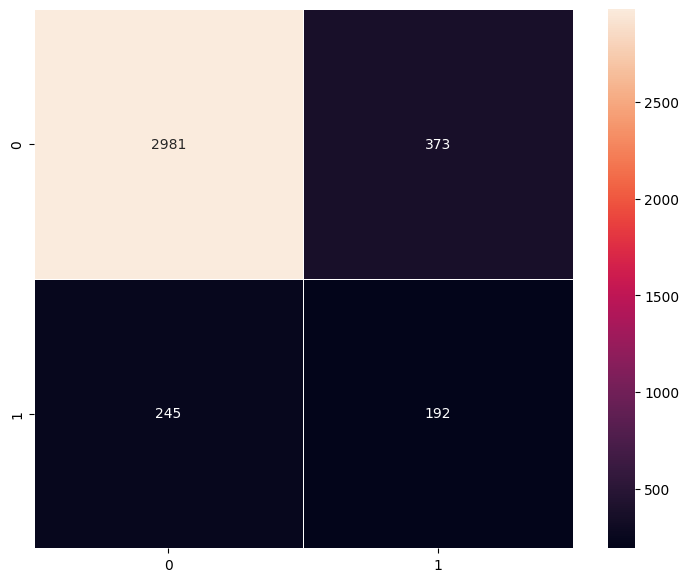

In [26]:
confusion_matrix = tf.math.confusion_matrix(y_test.T[0], np.round(cnn_model.predict(x_test).T[0]))
f, ax = plt.subplots(figsize=(9, 7))
sn.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.5,
    fmt="d",
    square=True,
    ax=ax
)
plt.show()

## A simple MLP model: A comparison

For a rather small comparison a simple MLP model, equivalent to the third component of our CNN, was trained under the same training environment with the exact same dataset. Our focus in this comparison is F1 score evaluation metric.

In [27]:
mlp_model = keras.Sequential([    
    keras.Input(shape=(x.shape[1],)),
    layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(l2_reg)),
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(l2_reg)),
    layers.Dense(1, activation='sigmoid')
])

mlp_model.compile(loss="binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy", "precision", "recall", tf.keras.metrics.F1Score(threshold=0.5)])

mlp_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       188,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,481 (767.50 KB)

 Trainable params: 196,481 (767.50 KB)

 Non-trainable params: 0 (0.00 B)

## MLP training

In [28]:
training_history = mlp_model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, shuffle=True, 
                           callbacks=[early_stop], validation_data=(x_test, y_test))

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5372 - f1_score: 0.4987 - loss: 1.1592 - precision: 0.5439 - recall: 0.4603 - val_accuracy: 0.8613 - val_f1_score: 0.2006 - val_loss: 0.9405 - val_precision: 0.2986 - val_recall: 0.1510
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6321 - f1_score: 0.6090 - loss: 0.8894 - precision: 0.6498 - recall: 0.5730 - val_accuracy: 0.7681 - val_f1_score: 0.3029 - val_loss: 0.7824 - val_precision: 0.2318 - val_recall: 0.4371
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6738 - f1_score: 0.6763 - loss: 0.7723 - precision: 0.6712 - recall: 0.6815 - val_accuracy: 0.8649 - val_f1_score: 0.2849 - val_loss: 0.6032 - val_precision: 0.3656 - val_recall: 0.2334
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6831 - f1_score: 0.6941 - loss: 0.7114 - precision: 0.6709 - recall: 0.7189 - val_accuracy: 0.8686 - val_f1_score: 0.2500 - val_loss: 0.5181 - val_precision: 0.3656 - val_rec

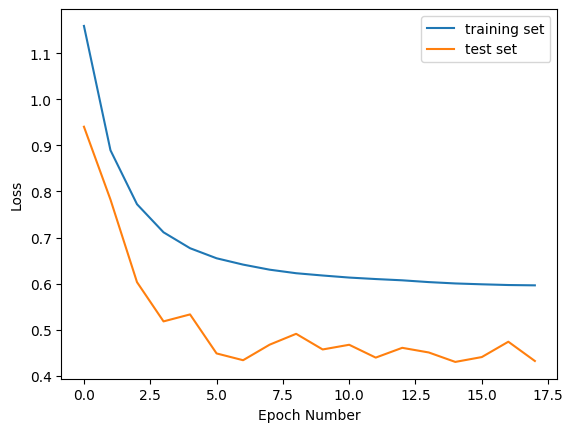

In [29]:
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.plot(training_history.history['loss'], label='training set')
plt.plot(training_history.history['val_loss'], label='test set')
plt.legend()

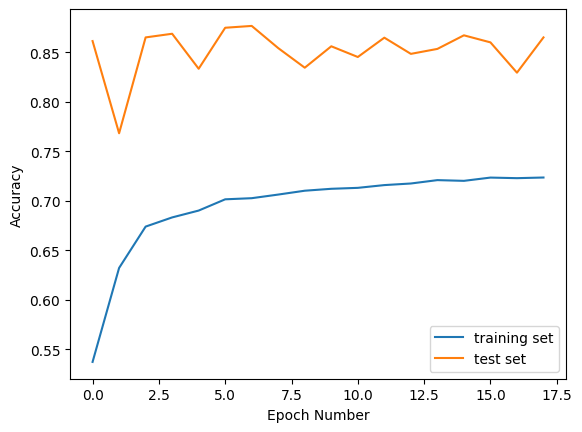

In [30]:
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.plot(training_history.history['accuracy'], label='training set')
plt.plot(training_history.history['val_accuracy'], label='test set')
plt.legend()

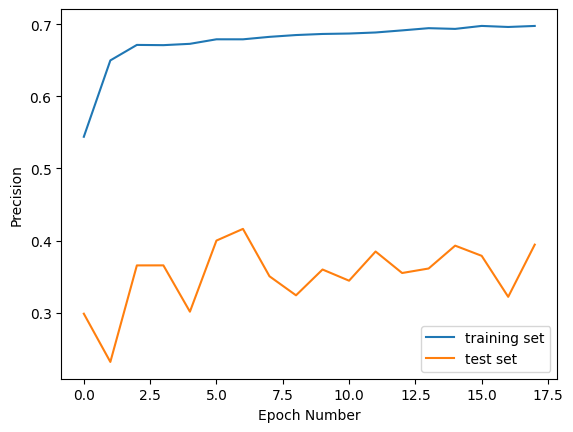

In [31]:
plt.xlabel('Epoch Number')
plt.ylabel('Precision')
plt.plot(training_history.history['precision'], label='training set')
plt.plot(training_history.history['val_precision'], label='test set')
plt.legend()

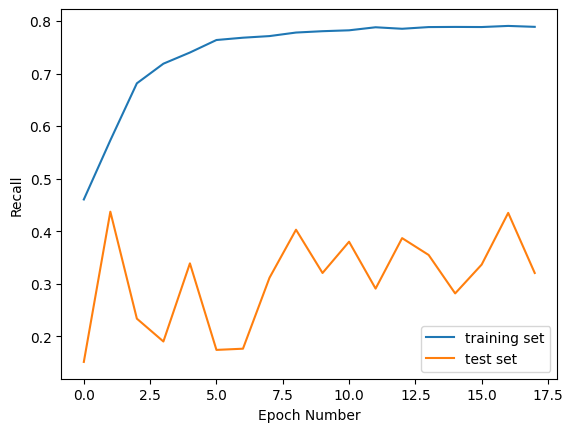

In [32]:
plt.xlabel('Epoch Number')
plt.ylabel('Recall')
plt.plot(training_history.history['recall'], label='training set')
plt.plot(training_history.history['val_recall'], label='test set')
plt.legend()

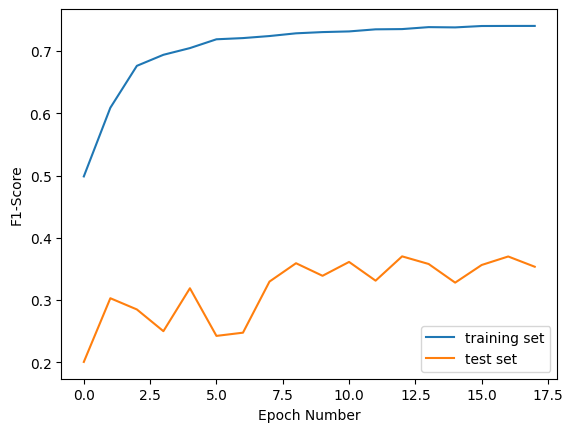

In [33]:
plt.xlabel('Epoch Number')
plt.ylabel('F1-Score')
plt.plot(training_history.history['f1_score'], label='training set')
plt.plot(training_history.history['val_f1_score'], label='test set')
plt.legend()

## MLP performance

In [34]:
score = mlp_model.evaluate(x_train, y_train)
print("Train loss:", score[0])
print("Train accuracy:", score[1])
print("Train precision:", score[2])
print("Train recall:", score[3])
print("Train f1-score:", score[4])

853/853 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step - accuracy: 0.7279 - f1_score: 0.7324 - loss: 0.5916 - precision: 0.7206 - recall: 0.7446
Train loss: 0.591623842716217
Train accuracy: 0.7279390096664429
Train precision: 0.7205986380577087
Train recall: 0.7445763945579529
Train f1-score: [0.7323913]


In [35]:
score = mlp_model.evaluate(x_test, y_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])
print("Test precision:", score[2])
print("Test recall:", score[3])
print("Test f1-score:", score[4])

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - accuracy: 0.8649 - f1_score: 0.3535 - loss: 0.4322 - precision: 0.3944 - recall: 0.3204          
Test loss: 0.43216055631637573
Test accuracy: 0.864943265914917
Test precision: 0.39436620473861694
Test recall: 0.32036614418029785
Test f1-score: [0.3535353]


119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 326us/step


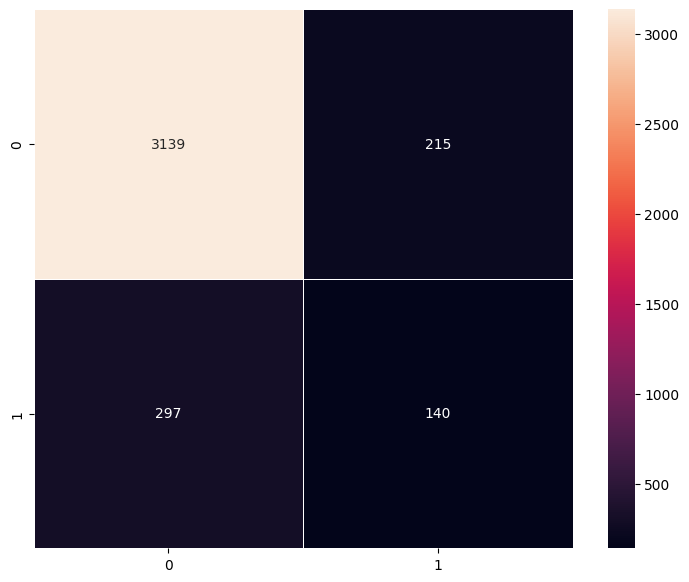

In [36]:
confusion_matrix = tf.math.confusion_matrix(y_test.T[0], np.round(mlp_model.predict(x_test).T[0]))
f, ax = plt.subplots(figsize=(9, 7))
sn.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.5,
    fmt="d",
    square=True,
    ax=ax
)
plt.show()

## Conclusion

Although we successfully applied CNN to predict student dropout, achieving good validation results with F1 scores rounding 0.38, a reasonable improvement to the results obtained when using more traditional machine learning approaches [2], a much simpler and more efficient MLP model was able to achieve nearly as good results, with F1 scores rounding 0.36. This shows that although possible, CNNs shouldn't be the first choice for tabular data. The nature of the problem also explains the rather "poor" results, as a lot of the features in the original dataset could be argued to have very little to no correlation to whether a student drops the course or not.

## Bibliography

[1] Mamani, E. L. (2023). Expanded Convolutional Network for Tabular Data. <br>
[2] Clara, R. V. (2026). A data-driven approach to first-year first-time student dropout in UAlg. Master of Science thesis in Informatics Engineering. UAlg